# Artificial Neural Network (ANN) Model for Hepatitis C Classification

In [1]:
!pip install minisom

  Preparing metadata (setup.py) ... - \ done
  Created wheel for minisom: filename=MiniSom-2.3.2-py3-none-any.whl size=10650 sha256=a71582fbb1f12ba989a097a0012dcadde86e15133b0681e0673b2233de43cf77
  Stored in directory: /root/.cache/pip/wheels/b4/f6/8a/9daf8831901c3e3805775633404248f10663d1c80b7e5a1314
Successfully built minisom


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set(style="darkgrid")
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import os
import cv2

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.cluster import KMeans
import minisom
from tensorflow.keras.utils import to_categorical

2024-04-28 12:30:08.233572: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-28 12:30:08.233685: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-28 12:30:08.341596: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Artificial Neural Networks (ANN)

In [3]:
# Read dataset and impute null values

def read_dataset():
  # Reads dataset
    df = pd.read_csv("/kaggle/input/hepatitiscdata/hcvdat0.csv")

  #Drops Unnamed: 0 column
    df.drop("Unnamed: 0", axis=1, inplace=True)

  #Fills missing values
    df['ALB'].fillna(df['ALB'].median(), inplace=True)
    df['ALP'].fillna(df['ALP'].median(), inplace=True)
    df['ALT'].fillna(df['ALT'].median(), inplace=True)
    df['CHOL'].fillna(df['CHOL'].median(), inplace=True)
    df['PROT'].fillna(df['PROT'].median(), inplace=True)

    return df

In [4]:
# Read and preprocessing

def preprocessing():
    df = read_dataset()

  #Maps values
    df['Category'] = df['Category'].map({
        '0=Blood Donor': 0,
        '0s=suspect Blood Donor':1,
        '1=Hepatitis':2,
        '2=Fibrosis':3,
        '3=Cirrhosis':4
        })

  #Maps SEX Column
    df['Sex'] = df['Sex'].map({
        'm': 1,
        'f': 2
    })

    return df

In [5]:
#Oversampling & Spliting

def oversample_and_split():
  #Preprocessing
    df = preprocessing()

  #Prints statistical description
    print(df.describe())

  #Oversample using SMOTE method
    x, y = df.drop('Category', axis=1), df['Category']
    smote = SMOTE()
    x, y = smote.fit_resample(x, y)

  # Scales features with MinMaxScaler

    cols_to_scale = x.drop('Sex', axis=1).columns
    cols_to_scale

    scale = MinMaxScaler()
    scalled = scale.fit_transform(x[cols_to_scale])

    i = 0
    for col in cols_to_scale:
        x[col] = scalled[:,i]
        i += 1

  #Split
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

    return X_train, X_test, y_train, y_test


In [6]:
#Confusion Matrix

def plot_confusion_matrix(y_test, y_pred, name):
  #Calculate
    conf_mat = confusion_matrix(y_true=y_test, y_pred=y_pred)

  #Define the class names and labels
    class_list = ['0=Blood Donor', '0s=suspect Blood Donor', '1=Hepatitis', '2=Fibrosis', '3=Cirrhosis']

  #Create a figure and axis
    fig, ax = plt.subplots(figsize=(25,15))

  #Generate heatmap
    sns.heatmap(conf_mat, annot=True, ax=ax, cmap='summer', fmt='g', annot_kws={"size":25})

  #Set axis labels & title
    ax.set_xlabel('Predicted labels', fontsize=20)
    ax.set_ylabel('True labels', fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    ax.set_title('Confusion Matrix of '+ name, fontsize=30)

  #Set tick labels for class names
    ax.xaxis.set_ticklabels(class_list)
    ax.yaxis.set_ticklabels(class_list)

  #Display
    plt.show()

In [7]:
# True Values versus Predicted Values Diagram

def plot_real_pred_val(y_test, ypred, name):
    plt.figure(figsize=(25,15))
    class_list = ['0=Blood Donor', '0s=suspect Blood Donor', '1=Hepatitis', '2=Fibrosis', '3=Cirrhosis']
    acc = accuracy_score(y_test, ypred)

  # plot true(white) and predicted(red)
    plt.scatter(range(len(ypred)), ypred, color="red", lw=5,
                        label="Predicted", s=300, alpha=0.9)
    plt.scatter(range(len(y_test)), y_test, color="white", lw=5,
                        label="Actual", s=300, alpha=0.9)

  # Set plot title, x-axis label and legend
    plt.title("Predicted Values vs True Values of "+ name, fontsize=30)
    plt.xlabel("Accuracy: " + str(round((acc * 100), 3)) + "%", fontsize=25)
    plt.legend(fontsize=25)

  # Sey y-axis tick positions & labels on classlist
    plt.yticks(range(len(class_list)), class_list, fontsize=15)
    plt.xticks(fontsize=15)

  #Add grid lines and set background
    plt.grid(True, alpha=0.75, lw=1, ls='-.')
    plt.gca().set_facecolor('dimgray')

  #Disply
    plt.show()

In [8]:
def plot_accuracy(history, name):
    # Create a figure and axes
    fig, ax = plt.subplots(1, 2, figsize=(20, 5))

    # Plotting accuracy
    ax[0].plot(history['accuracy'], label='Training Accuracy', color='blue')
    ax[0].plot(history['val_accuracy'], label='Validation Accuracy', color='orange')
    ax[0].set_title('Model Accuracy', fontsize=20)
    ax[0].set_xlabel('Epochs', fontsize=15)
    ax[0].set_ylabel('Accuracy', fontsize=15)
    ax[0].legend(fontsize=12)

    # Plotting loss
    ax[1].plot(history['loss'], label='Training Loss', color='blue')
    ax[1].plot(history['val_loss'], label='Validation Loss', color='orange')
    ax[1].set_title('Model Loss', fontsize=20)
    ax[1].set_xlabel('Epochs', fontsize=15)
    ax[1].set_ylabel('Loss', fontsize=15)
    ax[1].legend(fontsize=12)

    # Remove background grid
    ax[0].grid(False)
    ax[1].grid(False)

    # Set background color
    fig.patch.set_facecolor('lightgray')

    # Adjust layout and display plot
    plt.tight_layout()
    plt.show()


In [9]:
# Predicting Result

def prediction(model, X_test, y_test, name):
  # Perform predictions using the model
    pred = model.predict(X_test)

  # convert predict possibilities into class labels
    y_pred = np.array([np.argmax(pred[i]) for i in range(len(pred))])

  #Calculate accuracy & print
    accuracy = accuracy_score(y_pred, y_test, normalize=True)
    print('Accuracy Score for '+ name + ':', accuracy, '\n')

  #Generate & print classification report
    print('Classification Report for '+ name + ':\n', classification_report(y_pred, y_test))

  # Return the predicted class labels
    return y_pred

## Building and Training ANN Model

In [10]:
def build_train_ann(X_train, y_train):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(512, input_shape=(12,), activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(5, activation='softmax')
    ])

  # Display the model summary
    print(model.summary())

  # Compile the ANN using the Adam optimizer & categorical cross-entropy loss
    model.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

  # Create EarlyStopping callback
    early_stopping = EarlyStopping(monitor='val_loss',
                                     patience=100,
                                     restore_best_weights=True)

  #Train the ANN with early stopping
    history = model.fit(X_train, y_train, batch_size=64,
                          validation_split=0.20, epochs=200, shuffle=True,
                          callbacks=[early_stopping])

  #Save the trained model
    model.save('hepatitisc_model_ann.h5')

  #Save training history into a npy file
    np.save('hepatitisc_model_ann.npy', history.history)

  #Print keys of the history dictonary
    print(history.history.keys())


/tmp/ipykernel_23/1754272503.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ALB'].fillna(df['ALB'].median(), inplace=True)
/tmp/ipykernel_23/1754272503.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

         Category         Age         Sex         ALB         ALP         ALT  \
count  615.000000  615.000000  615.000000  615.000000  615.000000  615.000000   
mean     0.386992   47.408130    1.386992   41.620732   68.222927   28.441951   
std      1.052294   10.055105    0.487458    5.775935   25.646364   25.449889   
min      0.000000   19.000000    1.000000   14.900000   11.300000    0.900000   
25%      0.000000   39.000000    1.000000   38.800000   52.950000   16.400000   
50%      0.000000   47.000000    1.000000   41.950000   66.200000   23.000000   
75%      0.000000   54.000000    2.000000   45.200000   79.300000   33.050000   
max      4.000000   77.000000    2.000000   82.200000  416.600000  325.300000   

              AST         BIL         CHE        CHOL         CREA  \
count  615.000000  615.000000  615.000000  615.000000   615.000000   
mean    34.786341   11.396748    8.196634    5.366992    81.287805   
std     33.090690   19.673150    2.205657    1.123499    49.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181,829 (710.27 KB)

...

None
Epoch 1/200
20/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2096 - loss: 1.6293  

I0000 00:00:1714307430.761898      88 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1714307430.781523      88 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2084 - loss: 1.6287 

W0000 00:00:1714307454.524265      89 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1714307455.143334      90 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


24/24 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.2081 - loss: 1.6285 - val_accuracy: 0.1930 - val_loss: 1.6074
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1840 - loss: 1.6217 - val_accuracy: 0.2172 - val_loss: 1.6069
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2108 - loss: 1.6062 - val_accuracy: 0.2172 - val_loss: 1.6051
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2056 - loss: 1.6066 - val_accuracy: 0.2172 - val_loss: 1.5997
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2096 - loss: 1.5966 - val_accuracy: 0.2172 - val_loss: 1.5863
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2151 - loss: 1.5824 - val_accuracy: 0.3807 - val_loss: 1.5480
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2673 - loss: 1.5520 - val_accuracy: 0.5308 - val_loss: 1.4978
Epoch 8/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3051 - loss: 1.5411 - val_accuracy: 0.5764 - val_loss: 1.4

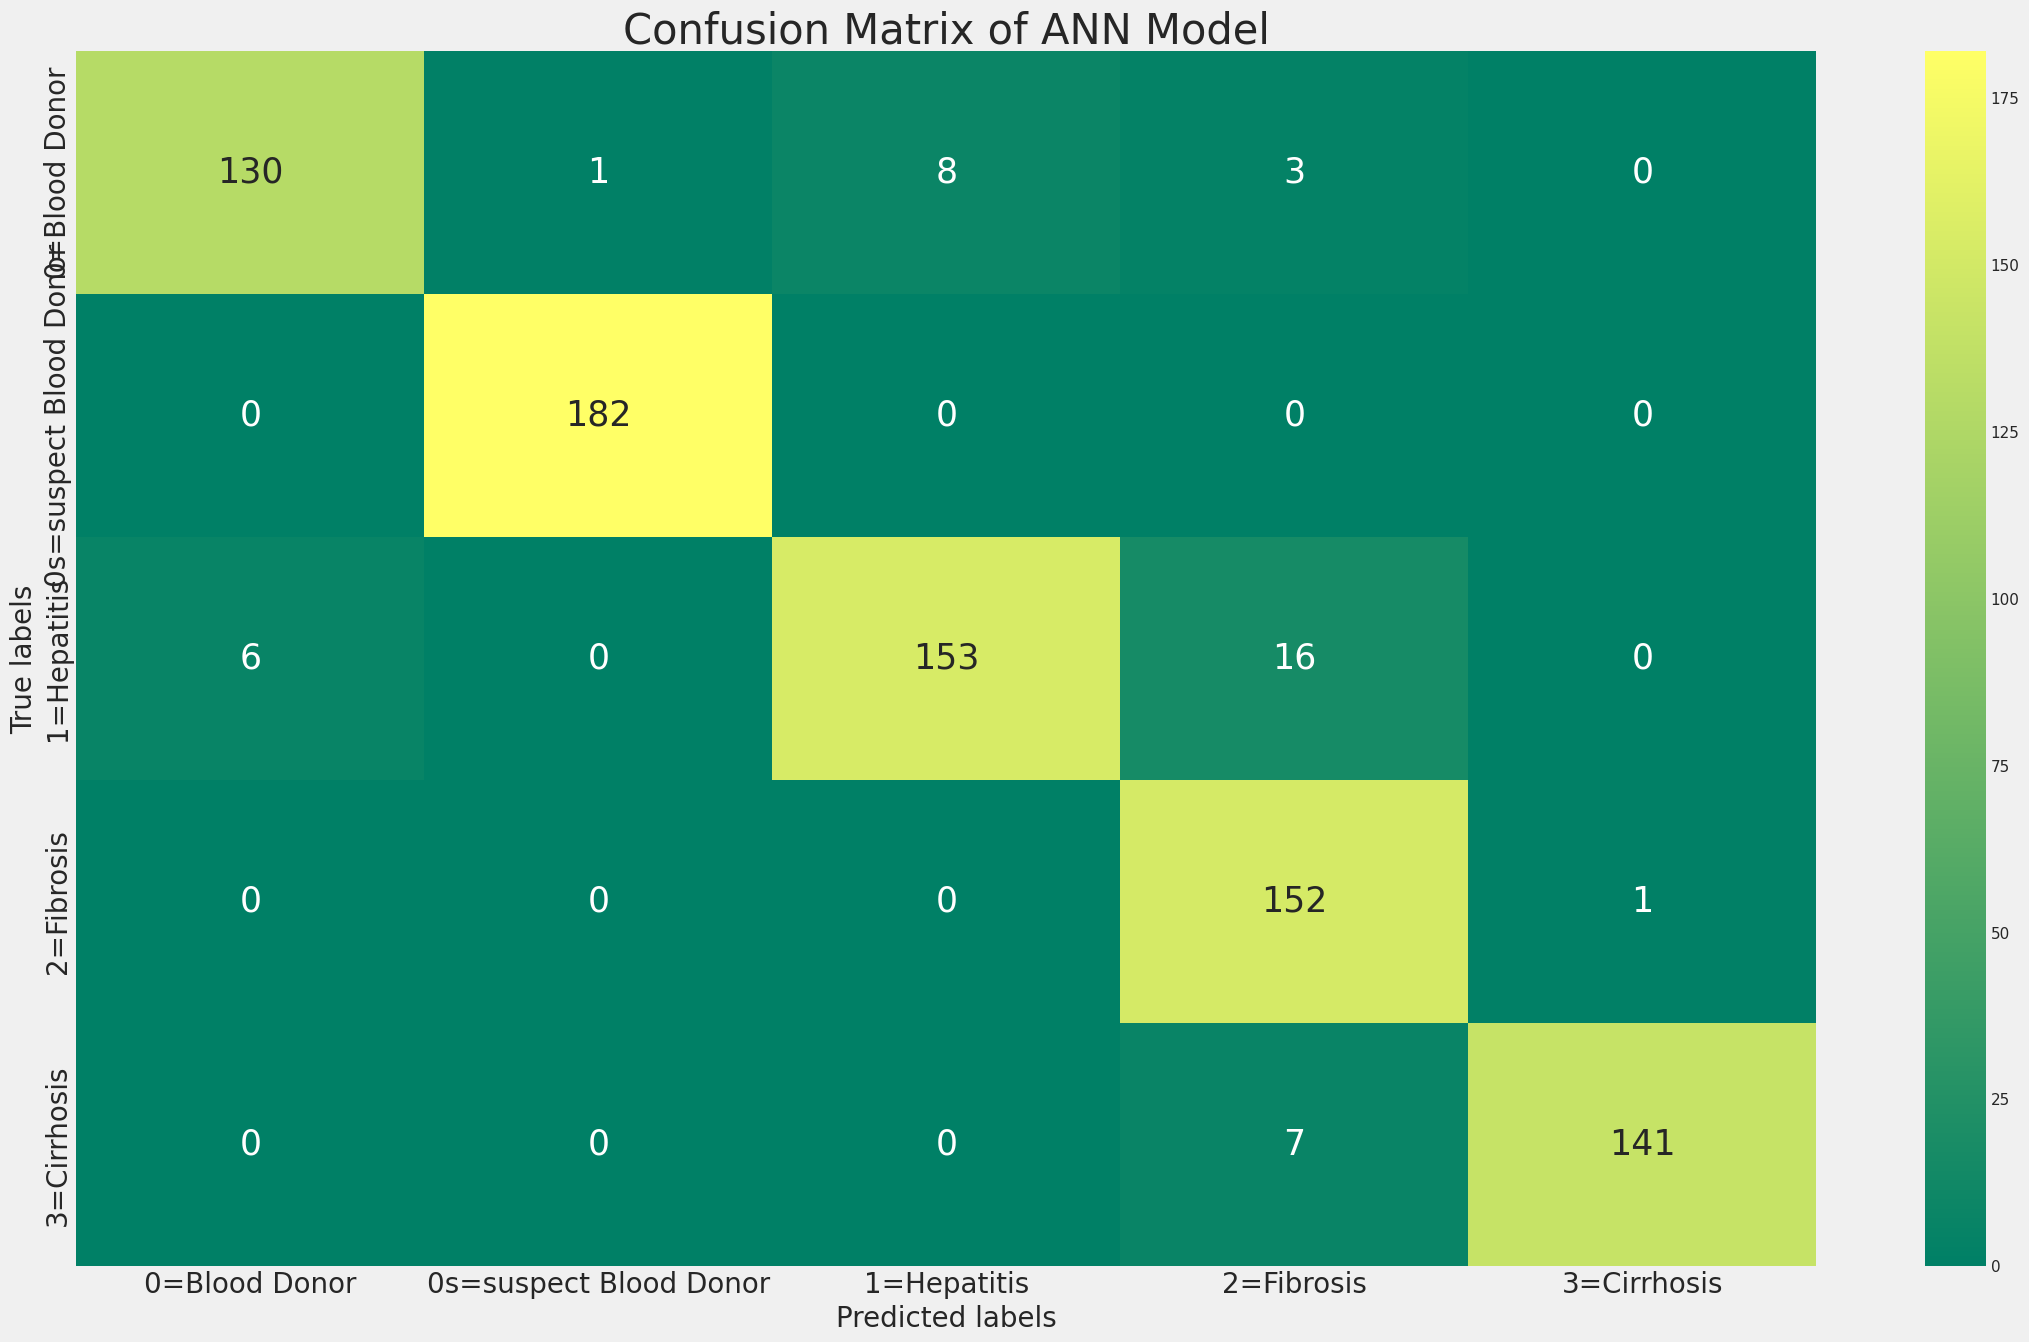

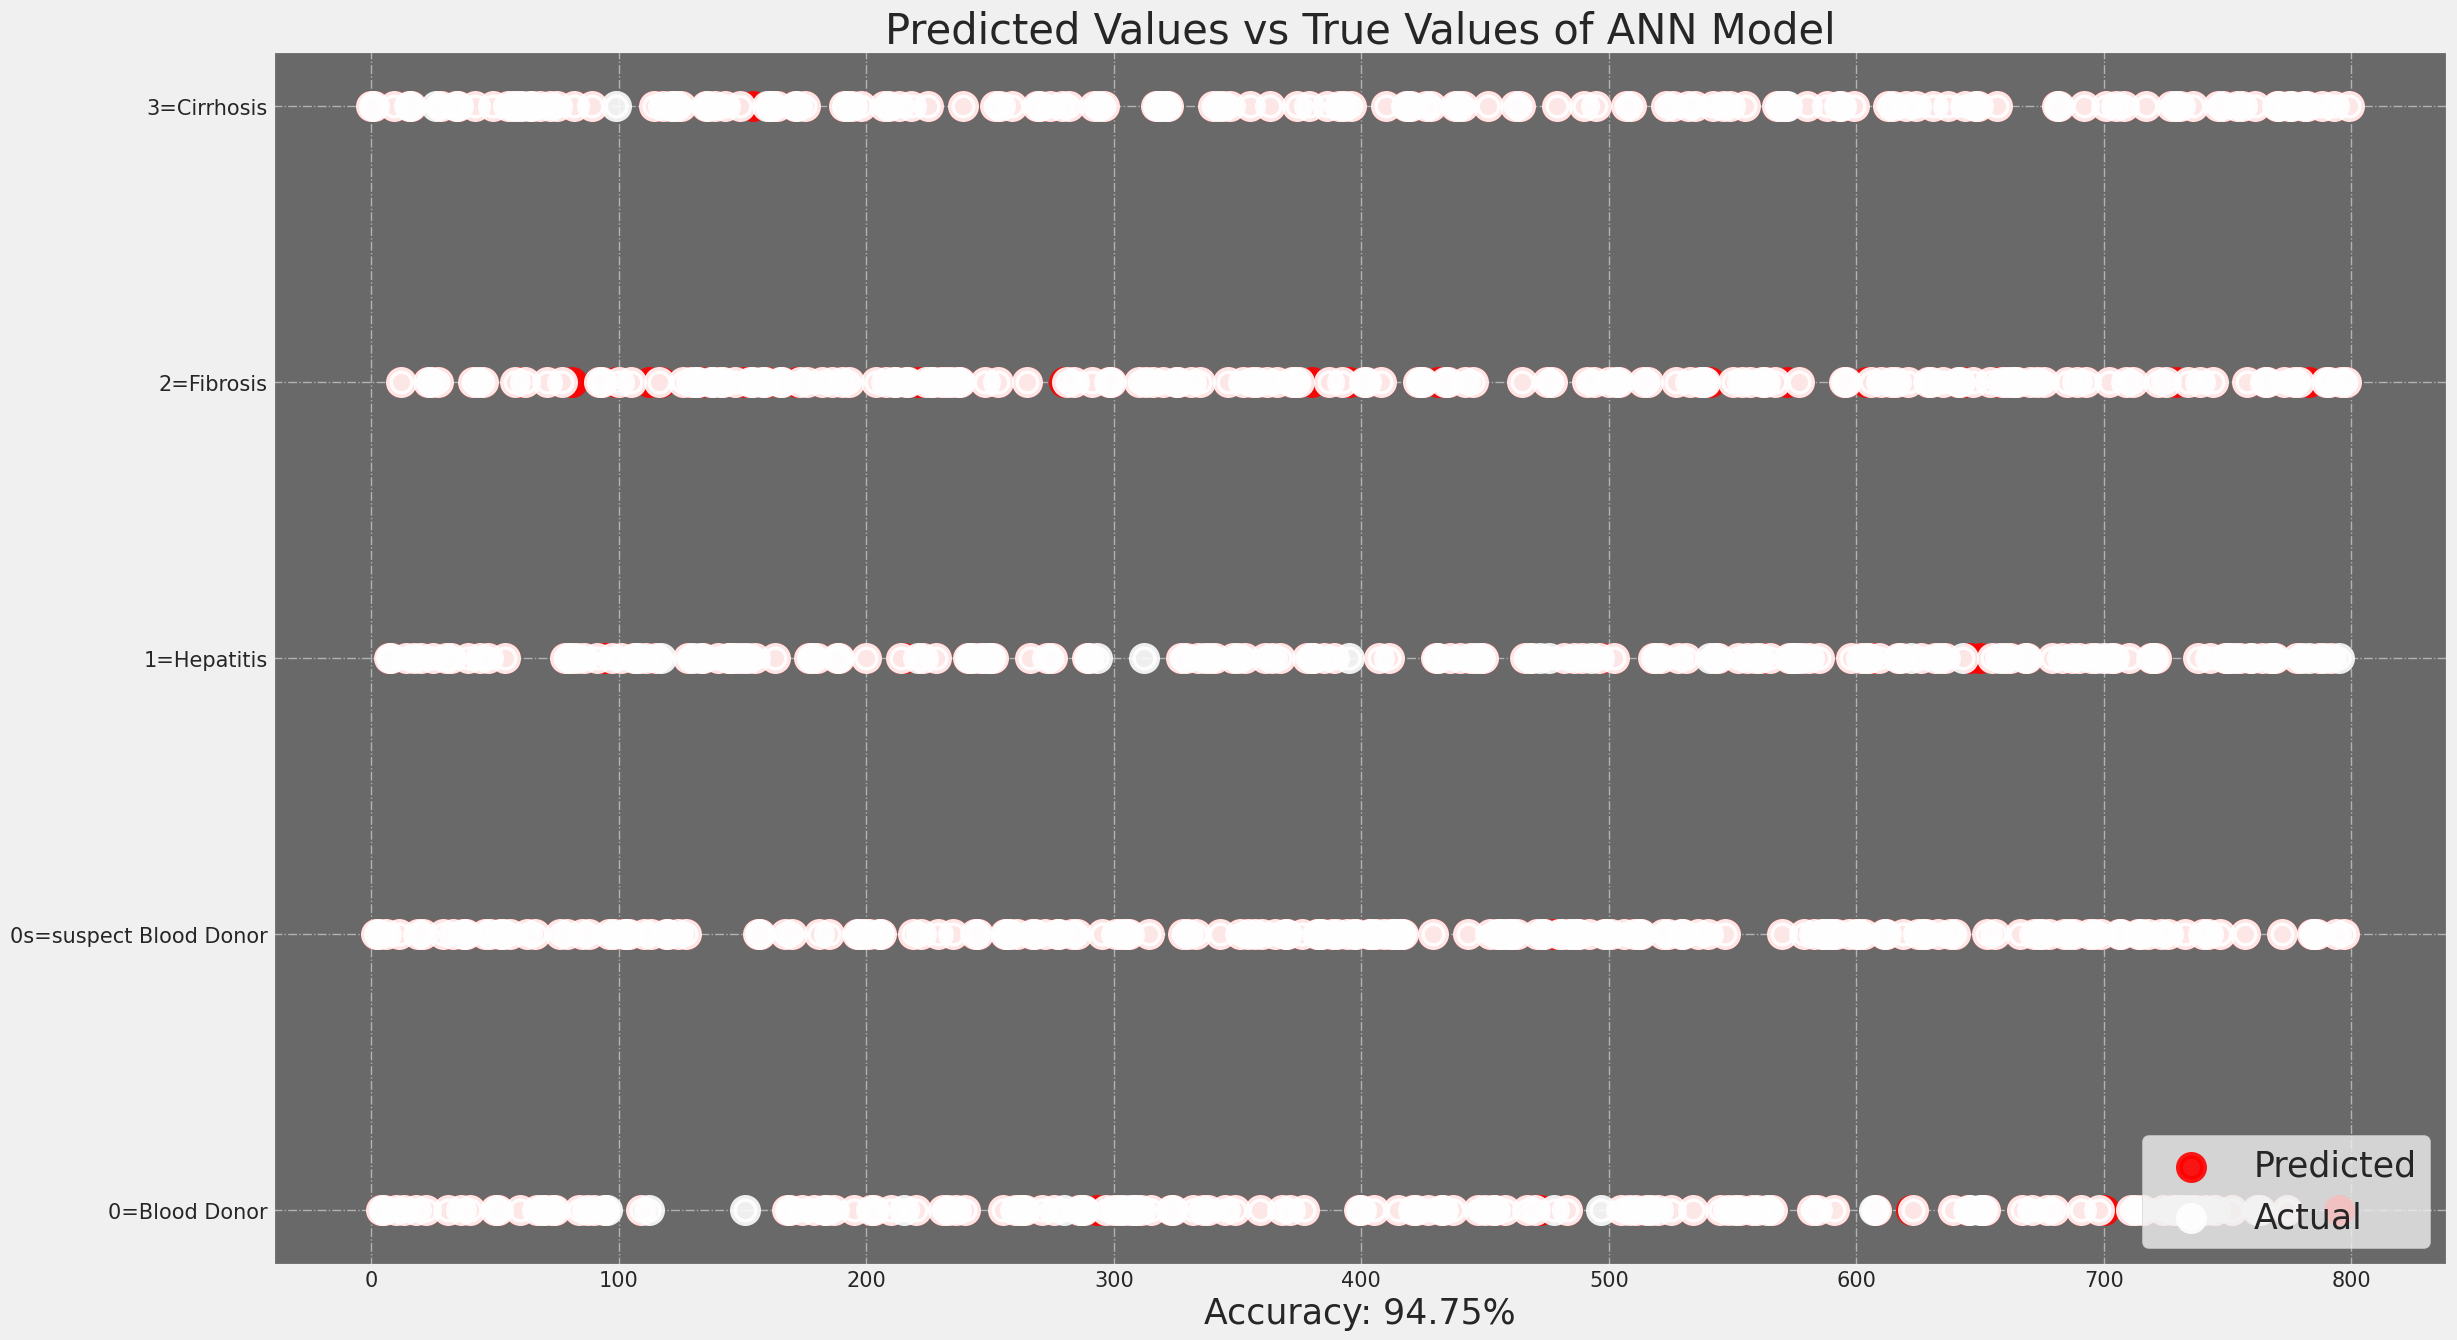

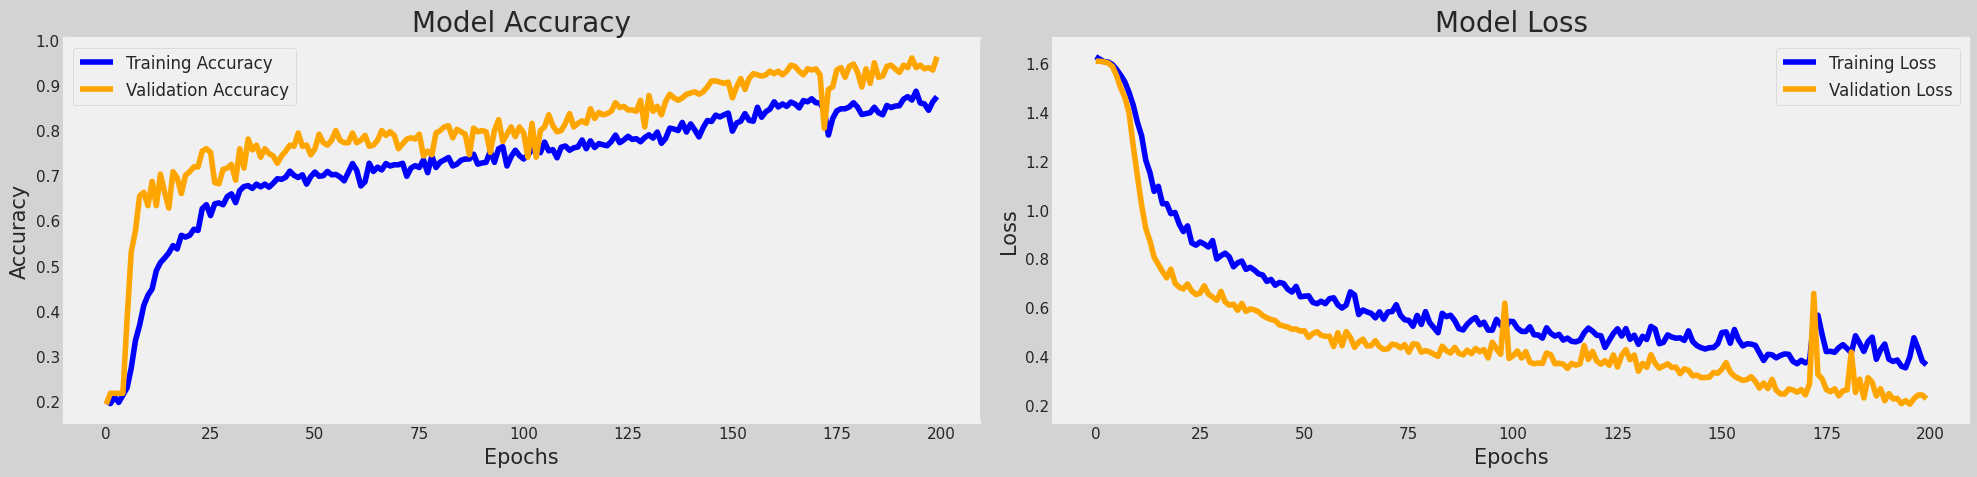

In [11]:
# Implementing ANN Model

def implement_ann_model():
  # Reads dataset
  X_train, X_test, y_train, y_test = oversample_and_split()

  #Convert y_train into one-hot-encoder format
  y_train_encoded = to_categorical(y_train, num_classes=5)

  # Build and train ANN
  build_train_ann(X_train, y_train_encoded)

  #Loads the ANN model
  ann_model = tf.keras.models.load_model('hepatitisc_model_ann.h5')

  #Gets predicted values
  y_pred = prediction(ann_model, X_test, y_test, 'ANN Model')

  #Plots confusion matrix
  plot_confusion_matrix(y_test, y_pred, 'ANN Model')

  #Plots true vs predicted values
  plot_real_pred_val(y_test, y_pred, 'ANN Model')

  #Load the saved training history hepatitisc_model_ann
  history = np.load('hepatitisc_model_ann.npy', allow_pickle=True).item()

  #Plots accuracy
  plot_accuracy(history, 'ANN Model')

  #Plot loss
  #plot_loss(history, 'ANN Model')

#Implement ANN Model
model = implement_ann_model()